## Imports

In [88]:
import os
import torch
import json
import sys
from sklearn.preprocessing import StandardScaler

sys.path.append("../../MainProject/Assignment9")
from assignment9_functions import *


if torch.backends.mps.is_available():
    device = torch.device("mps")      # Mac GPU (Apple Silicon)
    print("Apple GPU")
elif torch.cuda.is_available():
    device = torch.device("cuda")     # Nvidia GPU / AMD ROCm GPU
    print("Nvidia/AMD GPU")
else:
    device = torch.device("cpu")
    print("CPU")


random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

CPU


## Load data and split

In [89]:
datafolder = "../../MainProject/Assignment9/data/kinect_good_preprocessed"

train_files, test_files = split_csvfiles(datafolder, random_seed, 0.9, 0)

train_data = load(train_files, datafolder)
test_data = load(test_files, datafolder)

print(train_data.columns.tolist())

['FrameNo', 'head_x', 'head_y', 'head_z', 'left_shoulder_x', 'left_shoulder_y', 'left_shoulder_z', 'left_elbow_x', 'left_elbow_y', 'left_elbow_z', 'right_shoulder_x', 'right_shoulder_y', 'right_shoulder_z', 'right_elbow_x', 'right_elbow_y', 'right_elbow_z', 'left_hand_x', 'left_hand_y', 'left_hand_z', 'right_hand_x', 'right_hand_y', 'right_hand_z', 'left_hip_x', 'left_hip_y', 'left_hip_z', 'right_hip_x', 'right_hip_y', 'right_hip_z', 'left_knee_x', 'left_knee_y', 'left_knee_z', 'right_knee_x', 'right_knee_y', 'right_knee_z', 'left_foot_x', 'left_foot_y', 'left_foot_z', 'right_foot_x', 'right_foot_y', 'right_foot_z']


## Try Data augmentation

In [90]:
def mirror_frames(X, Y):
    mirror_pairs = [
        (1, 3),
        (2, 4),
        (5, 6),
        (7, 8),
        (9, 10),
        (11, 12),
    ]

    X_mirrored = X.clone()
    Y_mirrored = Y.clone()

    for left, right in mirror_pairs:

        left_x = 2 * left
        right_x = 2 * right

        tmp_left_x = X_mirrored[:, left_x].clone()
        tmp_right_x = X_mirrored[:, right_x].clone()

        X_mirrored[:, left_x] = -tmp_right_x
        X_mirrored[:, right_x] = -tmp_left_x

        left_y = 2 * left + 1
        right_y = 2 * right + 1

        tmp_left_y = X_mirrored[:, left_y].clone()
        tmp_right_y = X_mirrored[:, right_y].clone()

        X_mirrored[:, left_y] = tmp_right_y
        X_mirrored[:, right_y] = tmp_left_y

        tmp_left_z = Y_mirrored[:, left].clone()
        tmp_right_z = Y_mirrored[:, right].clone()

        Y_mirrored[:, left] = tmp_right_z
        Y_mirrored[:, right] = tmp_left_z

    return X_mirrored, Y_mirrored


def rotate_y_frames_tensor(X, Y, angle_deg):
    """
    Rotate frames around Y axis using tensor operations

    Args:
        X: (n_samples, 26) - xy coordinates
        Y: (n_samples, 13) - z coordinates
        angle_deg: rotation angle in degrees

    Returns:
        X_rotated, Y_rotated
    """

    theta = torch.tensor(np.radians(angle_deg), dtype=torch.float32, device=X.device)
    cos_t = torch.cos(theta)
    sin_t = torch.sin(theta)

    X_rotated = X.clone()
    Y_rotated = Y.clone()

    # for each joint
    for joint_idx in range(13):

        x_idx = 2 * joint_idx
        z_idx = joint_idx

        x = X[:, x_idx]
        z = Y[:, z_idx]

        # rotation
        X_rotated[:, x_idx] = x * cos_t + z * sin_t
        Y_rotated[:, z_idx] = -x * sin_t + z * cos_t

    return X_rotated, Y_rotated


def add_noise_to_frames_tensor(X, Y,
                               noise_std_xy=0.002,
                               noise_std_z=0.001,
                               apply_to_z=True,
                               prob=0.5,
                               seed=None):
    """
    Add Gaussian noise to frame-based pose data

    Args:
        X: (n_samples, 26) - xy coordinates
        Y: (n_samples, 13) - z coordinates
    """

    if seed is not None:
        torch.manual_seed(seed)

    X_noisy = X.clone()
    Y_noisy = Y.clone()

    # Decide which frames get noise
    mask = torch.rand(X.shape[0], device=X.device) < prob

    if mask.any():

        # ---- noise for X (xy joints) ----
        noise_xy = torch.randn_like(X_noisy[mask]) * noise_std_xy
        X_noisy[mask] = X_noisy[mask] + noise_xy

        # ---- noise for Y (depth) ----
        if apply_to_z:
            noise_z = torch.randn_like(Y_noisy[mask]) * noise_std_z
            Y_noisy[mask] = Y_noisy[mask] + noise_z

    return X_noisy, Y_noisy

## Split data into input and target

In [91]:

x_train, y_train = input_target_split(train_data)
x_test, y_test = input_target_split(test_data)

# Scale data - New addition implemented in Assignment 10 - Made it worse?
# scaler = StandardScaler()
# scaler.fit(x_train)
# x_train = scaler.transform(x_train)
# x_test = scaler.transform(x_test)


# Convert to tensors
x_train = torch.tensor(x_train.values, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train.values, dtype=torch.float32).to(device)
x_test = torch.tensor(x_test.values, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test.values, dtype=torch.float32).to(device)


# Data augmentation - Mirroring
x_train_mirror, y_train_mirror = mirror_frames(x_train, y_train)
x_train = torch.cat([x_train, x_train_mirror], dim=0)
y_train = torch.cat([y_train, y_train_mirror], dim=0)

# Data augmentation - Rotate y frames 
#x_train_rot, y_train_rot = rotate_y_frames_tensor(x_train, y_train, angle_deg = 15)
#x_train = torch.cat([x_train, x_train_rot], dim=0)
#y_train = torch.cat([y_train, y_train_rot], dim=0)

# Data augmentation - Add noise
#x_train_noisy, y_train_noisy = add_noise_to_frames_tensor(x_train, y_train, noise_std_xy = 0.002, noise_std_z = 0.001, prob = 0.5)
#x_train = torch.cat([x_train, x_train_noisy], dim=0)
#y_train = torch.cat([y_train, y_train_noisy], dim=0)


## Define paths to stored champion model

In [92]:
#model_root = "../../MainProject/models"
model_root = "../z_pred_models"
metadata_path = os.path.join(model_root, "metadata", "champion_info.json")
model_path = os.path.join(model_root, "champion", "champion_model.pt")


# Load config

In [93]:
with open(metadata_path, "r") as f:
    champion_info = json.load(f)

best_config = champion_info["hyperparameters"]

print("Loaded champion config:")
print(best_config)


Loaded champion config:
{'hidden_layers': [256, 128, 64], 'learning_rate': 0.001, 'dropout': 0, 'activation': 'relu', 'optimizer': 'adam', 'epochs': 500, 'patience': 5}


# Build and retrain best model

In [94]:
best_model = build_model(best_config, device)

result = train_one_model(
    best_model,
    best_config,
    x_train,
    y_train,
    x_train,
    y_train,
)
best_model.load_state_dict(result["best_state"])


<All keys matched successfully>

# Evaluate

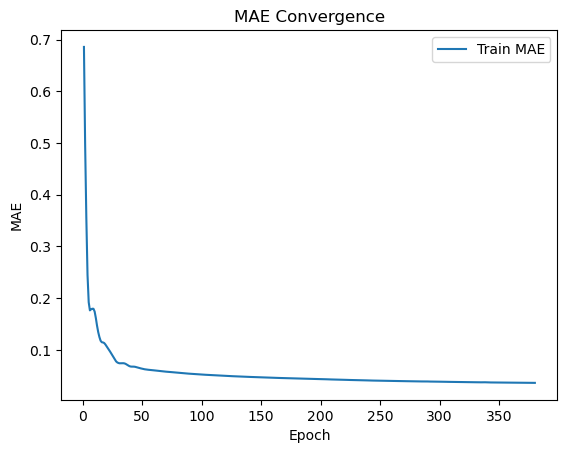

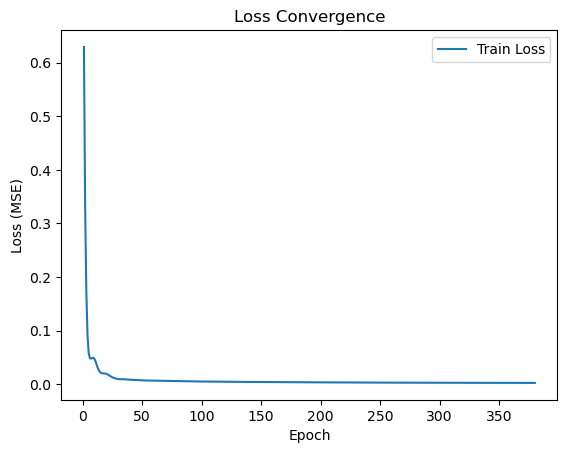

In [95]:
import matplotlib.pyplot as plt

history = result["history"]

epochs = [h["epoch"] for h in history]
train_mae = [h["train_mae"] for h in history]
train_loss = [h["train_loss"] for h in history]


# --- MAE ---
plt.figure()
plt.plot(epochs, train_mae, label="Train MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("MAE Convergence")
plt.legend()
plt.show()

# --- LOSS ---
plt.figure()
plt.plot(epochs, train_loss, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Loss Convergence")
plt.legend()
plt.show()



In [96]:
loss_fn = nn.MSELoss()

# ---- TRAIN EVALUATION ----
train_loss, train_metrics, _ = evaluate_model(
    best_model,
    x_train,
    y_train,
    loss_fn
)

print("\nTrain metrics:")
print(f"Train Loss (MSE):  {train_metrics['mse']:.6f}")
print(f"Train MAE:  {train_metrics['mae']:.6f}")
print(f"Train R2:   {train_metrics['r2']:.6f}")
print(f"Train Bias: {train_metrics['bias']:.6f}")


# ---- TEST EVALUATION ----
test_loss, test_metrics, test_predictions = evaluate_model(
    best_model,
    x_test,
    y_test,
    loss_fn
)

print("\nTest metrics:")
print(f"Test Loss (MSE):  {test_metrics['mse']:.6f}")
print(f"Test MAE:  {test_metrics['mae']:.6f}")
print(f"Test R2:   {test_metrics['r2']:.6f}")
print(f"Test Bias: {test_metrics['bias']:.6f}")


Train metrics:
Train Loss (MSE):  0.002430
Train MAE:  0.036098
Train R2:   0.723616
Train Bias: -0.000173

Test metrics:
Test Loss (MSE):  0.004350
Test MAE:  0.049728
Test R2:   0.572527
Test Bias: 0.027036


In [97]:
joint_names = [
    "head", "left_shoulder", "left_elbow", "right_shoulder", "right_elbow",
    "left_hand", "right_hand", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_foot", "right_foot"
]

# --- MAE ---
errors = torch.abs(test_predictions - y_test)

mae_per_joint = torch.mean(errors, dim=0)

print("\nMAE per joint:")
for i, joint in enumerate(joint_names):
    print(f"{joint}: {mae_per_joint[i].item() * 100:.6f} cm")
print(f"Average MAE:  {test_metrics['mae'] * 100:.6f} cm")

# --- MSE ---
mse_per_joint = torch.mean((test_predictions - y_test) ** 2, dim=0)

print("\nMSE per joint:")
for i, joint in enumerate(joint_names):
    print(f"{joint}: {mse_per_joint[i].item() * 100 * 100:6f} cm^2")
print(f"Average MSE:  {test_metrics['mse'] * 100 * 100:.6f} cm^2")



MAE per joint:
head: 4.759983 cm
left_shoulder: 4.107390 cm
left_elbow: 5.467664 cm
right_shoulder: 4.914419 cm
right_elbow: 5.522116 cm
left_hand: 6.759422 cm
right_hand: 6.298596 cm
left_hip: 4.389134 cm
right_hip: 4.262051 cm
left_knee: 4.645370 cm
right_knee: 4.676938 cm
left_foot: 4.430113 cm
right_foot: 4.412787 cm
Average MAE:  4.972768 cm

MSE per joint:
head: 41.124704 cm^2
left_shoulder: 29.584509 cm^2
left_elbow: 51.032486 cm^2
right_shoulder: 41.919323 cm^2
right_elbow: 51.040924 cm^2
left_hand: 72.511886 cm^2
right_hand: 66.145039 cm^2
left_hip: 30.184092 cm^2
right_hip: 29.279508 cm^2
left_knee: 38.440404 cm^2
right_knee: 41.277059 cm^2
left_foot: 35.115271 cm^2
right_foot: 37.904489 cm^2
Average MSE:  43.504597 cm^2
